In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

2026-03-01 22:58:56.116196: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# cargamos los datos
PROJECT_ROOT = Path().resolve().parent
PROCESSED_PATH = PROJECT_ROOT / 'data' / 'processed'

X_train = np.load(PROCESSED_PATH / 'X_train.npy')
X_test = np.load(PROCESSED_PATH / 'X_test.npy')
y_train = np.load(PROCESSED_PATH / 'y_train.npy')
y_test = np.load(PROCESSED_PATH / 'y_test.npy')

print('Train:', X_train.shape)
print('Test:', X_test.shape)

Train: (6400, 64, 64, 3)
Test: (1600, 64, 64, 3)


In [ ]:
IMG_SIZE = 128
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE, 3)

In [ ]:
inputs = layers.Input((INPUT_SHAPE))

# encoder
c1 = layers.Conv2D(64,3,activation="relu",padding="same")(inputs)
c1 = layers.Conv2D(64,3,activation="relu",padding="same")(c1)
p1 = layers.MaxPooling2D()(c1)

c2 = layers.Conv2D(128,3,activation="relu",padding="same")(p1)
c2 = layers.Conv2D(128,3,activation="relu",padding="same")(c2)
p2 = layers.MaxPooling2D()(c2)

c3 = layers.Conv2D(256,3,activation="relu",padding="same")(p2)
c3 = layers.Conv2D(256,3,activation="relu",padding="same")(c3)

# decoder
u1 = layers.UpSampling2D()(c3)
u1 = layers.Concatenate()([u1, c2])
c4 = layers.Conv2D(128,3,activation="relu",padding="same")(u1)
c4 = layers.Conv2D(128,3,activation="relu",padding="same")(c4)

u2 = layers.UpSampling2D()(c4)
u2 = layers.Concatenate()([u2, c1])
c5 = layers.Conv2D(64,3,activation="relu",padding="same")(u2)
c5 = layers.Conv2D(64,3,activation="relu",padding="same")(c5)

outputs = layers.Conv2D(3,3,activation="sigmoid",padding="same")(c5)

model = models.Model(inputs, outputs)

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 64, 64, 3)]       0         
                                                                 
 conv2d (Conv2D)             (None, 64, 64, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 32, 32, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 16, 16, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 16, 16, 128)       73856 

In [5]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    shuffle=True
)

Epoch 1/10
160/160 [==============================] - 106s 663ms/step - loss: 0.0077 - mae: 0.0599 - val_loss: 0.0068 - val_mae: 0.0554
Epoch 2/10
160/160 [==============================] - 109s 682ms/step - loss: 0.0063 - mae: 0.0529 - val_loss: 0.0060 - val_mae: 0.0503
Epoch 3/10
160/160 [==============================] - 112s 702ms/step - loss: 0.0058 - mae: 0.0502 - val_loss: 0.0056 - val_mae: 0.0483
Epoch 4/10
160/160 [==============================] - 123s 768ms/step - loss: 0.0055 - mae: 0.0480 - val_loss: 0.0053 - val_mae: 0.0466
Epoch 5/10
160/160 [==============================] - 117s 734ms/step - loss: 0.0053 - mae: 0.0472 - val_loss: 0.0052 - val_mae: 0.0461
Epoch 6/10
160/160 [==============================] - 113s 708ms/step - loss: 0.0050 - mae: 0.0457 - val_loss: 0.0051 - val_mae: 0.0460
Epoch 7/10
160/160 [==============================] - 114s 712ms/step - loss: 0.0049 - mae: 0.0451 - val_loss: 0.0050 - val_mae: 0.0461
Epoch 8/10
160/160 [============================

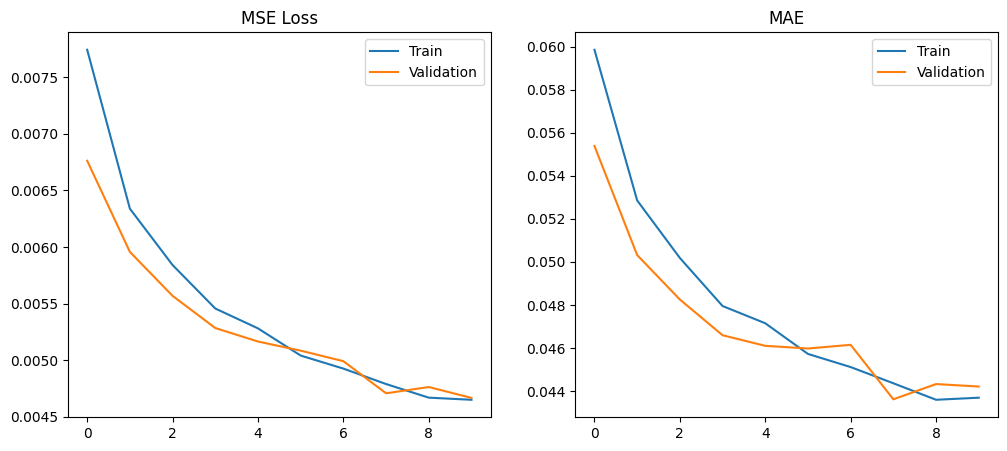

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# loss
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("MSE Loss")
plt.legend()

# MAE
plt.subplot(1,2,2)
plt.plot(history.history["mae"], label="Train")
plt.plot(history.history["val_mae"], label="Validation")
plt.title("MAE")
plt.legend()

plt.show()

In [9]:
test_loss, test_mae = model.evaluate(X_test, y_test)

print("Test MSE:", test_loss)
print("Test MAE:", test_mae)

50/50 [==============================] - 8s 168ms/step - loss: 0.0047 - mae: 0.0446
Test MSE: 0.004720690660178661
Test MAE: 0.04455423727631569


In [ ]:
def show_results(model, X, y, n=5):
    preds = model.predict(X[:n])
    
    plt.figure(figsize=(15, 6))
    
    for i in range(n):
        # input (blur)
        plt.subplot(3, n, i+1)
        plt.imshow(X[i])
        plt.axis("off")
        if i == 0:
            plt.title("Blurred")
        
        # output
        plt.subplot(3, n, i+n+1)
        plt.imshow(preds[i])
        plt.axis("off")
        if i == 0:
            plt.title("Deblurred (Model)")
        
        # original
        plt.subplot(3, n, i+2*n+1)
        plt.imshow(y[i])
        plt.axis("off")
        if i == 0:
            plt.title("Original")

    plt.tight_layout()
    plt.show()

1/1 [==============================] - 0s 346ms/step


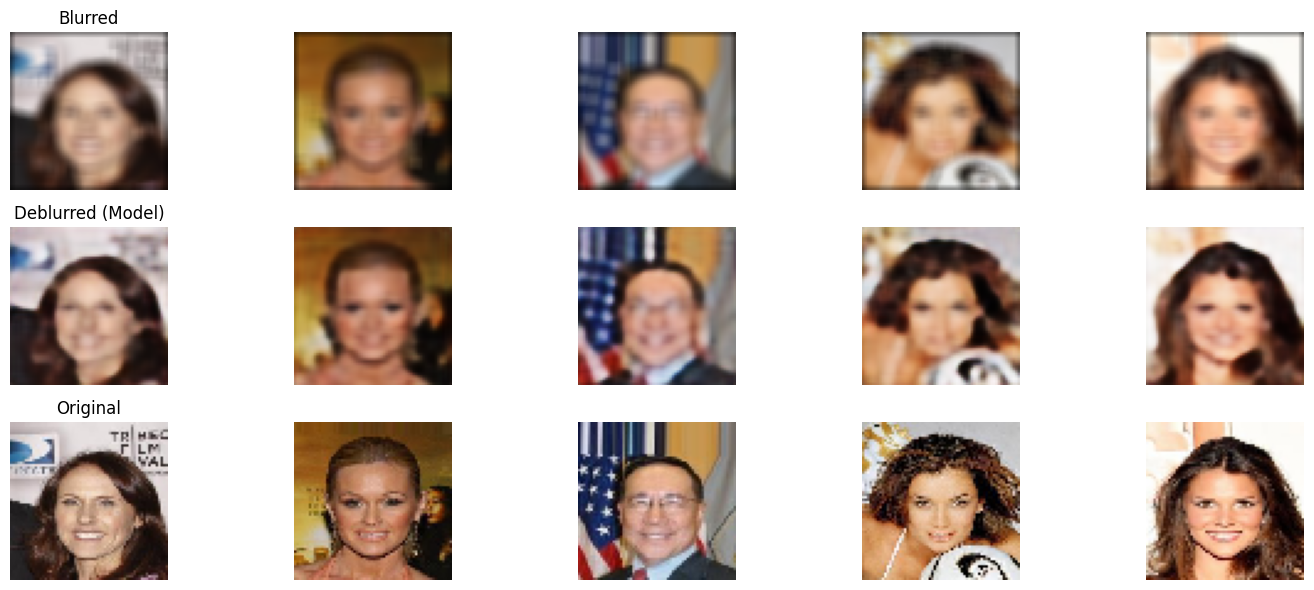

In [12]:
show_results(model, X_test, y_test, n=5)

In [ ]:
model.save("../models/deblur_model3_1.h5")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
